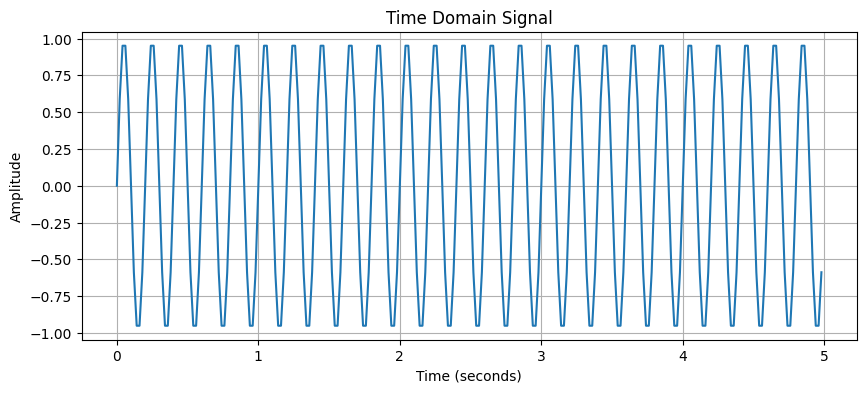

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time(x, fs):
    
    t_x = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)
    
    plt.figure(figsize=(10, 4))
    plt.plot(t_x, x)
    plt.title("Time Domain Signal")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


fs = 50  # sampling frequency 
duration = 5  # Duration length of the signal in seconds
t_x = np.linspace(0, duration, int(fs * duration), endpoint=False)  
x = np.sin(2 * np.pi * 5 * t_x)  # 5 Hz sine wave

plot_time(x, fs)


## Question 1b

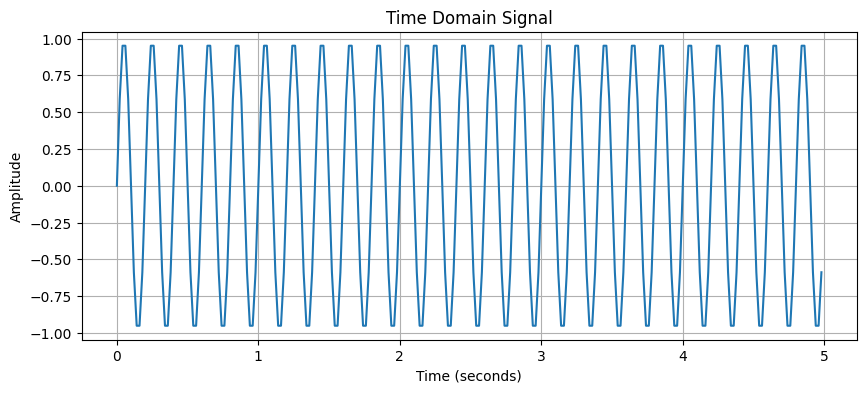

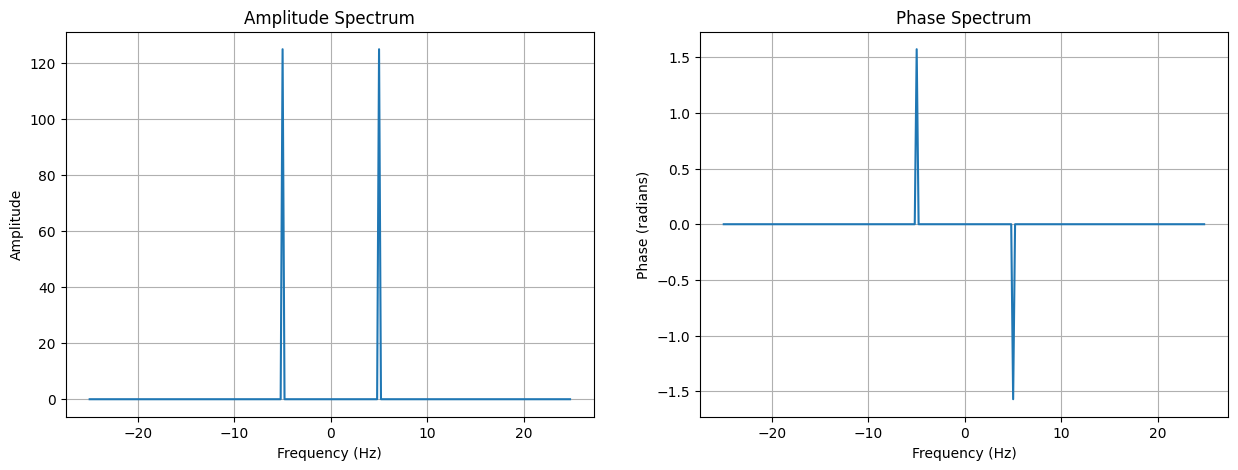

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def plot_freq(X, fs):
    n = len(X)
    freq = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    X_shifted = np.fft.fftshift(X)
    amplitude = np.abs(X_shifted)
    phase = np.angle(X_shifted)
    
    threshold=1e-5
    phase[amplitude < threshold] = 0
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(freq, amplitude)
    ax1.set_title("Amplitude Spectrum")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True)
    
    ax2.plot(freq, phase)
    ax2.set_title("Phase Spectrum")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (radians)")
    ax2.grid(True)
    plt.show()

fs = 50  # Sampling frequency

t = np.linspace(0, 5, int(5 * fs), endpoint=False)  # Time vector
x = np.sin(2 * np.pi * 5 * t)  # Sine wave

# the DFT of the signal
X = np.fft.fft(x)


plot_time(x, fs)
plot_freq(X, fs)


## Question 2


In [3]:
import numpy as np

def psd(x, w, fs):

    N = len(x)
    x_w = x * w
    X = np.fft.fft(x_w)
    S = np.sum(w ** 2)  # Sum of the squared window values
    freqs = np.fft.fftfreq(N, d=1/fs)
    pos_freqs = freqs[freqs >= 0]
    psd_vals = 2 * (np.abs(X[freqs >= 0]) ** 2) / (fs * S)
    
    return pos_freqs, psd_vals


# have to add comments for the orthognality

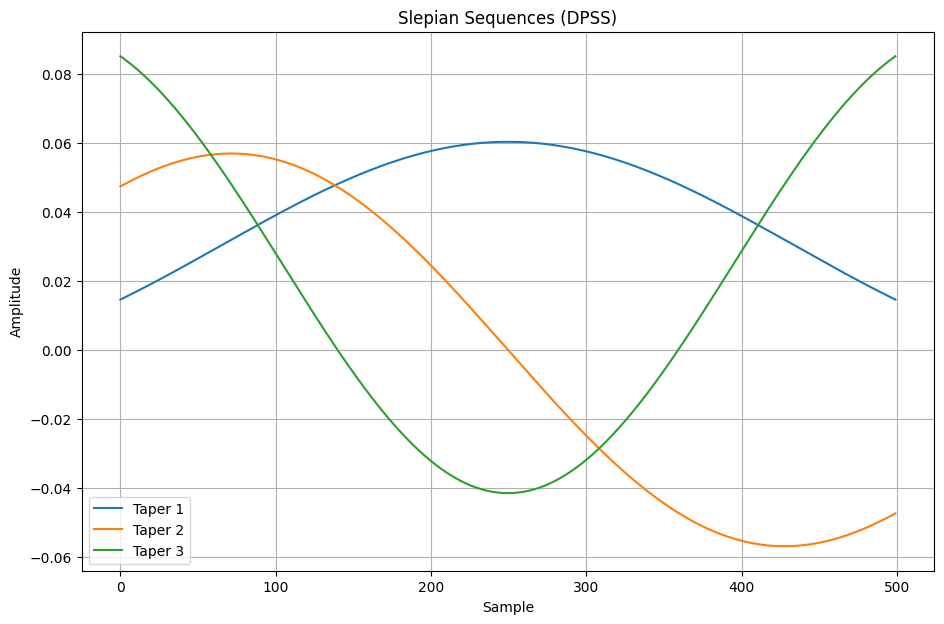

Orthogonality matrix:
 [[ 1.00000000e+00  2.29850861e-17 -7.37257477e-18]
 [ 2.29850861e-17  1.00000000e+00 -8.67361738e-19]
 [-7.37257477e-18 -8.67361738e-19  1.00000000e+00]]


In [4]:
import matplotlib.pyplot as plt
import scipy

M = 500  # Length of the taper
NW = 1  # Time-bandwidth parameter
tapers = scipy.signal.windows.dpss(M, NW, Kmax=3)


plt.figure(figsize=(11, 7))
for i, taper in enumerate(tapers):
    plt.plot(taper, label=f"Taper {i+1}")
plt.legend()
plt.title("Slepian Sequences (DPSS)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Verify orthogonality
orthogonality = np.array([[np.dot(t1, t2) for t2 in tapers] for t1 in tapers])
print("Orthogonality matrix:\n", orthogonality)


In [5]:
def multitaper(x, fs, k):

    N = len(x)
    NW = N / fs 
    tapers = scipy.signal.windows.dpss(N, NW, Kmax=k)
    
    psd_list = []
    for taper in tapers:
        f, psd_vals = psd(x, taper, fs)
        psd_list.append(psd_vals)
    
    multitaper_psd = np.mean(psd_list, axis=0)  
    return f, multitaper_psd


Sampling frequency: 44100 Hz


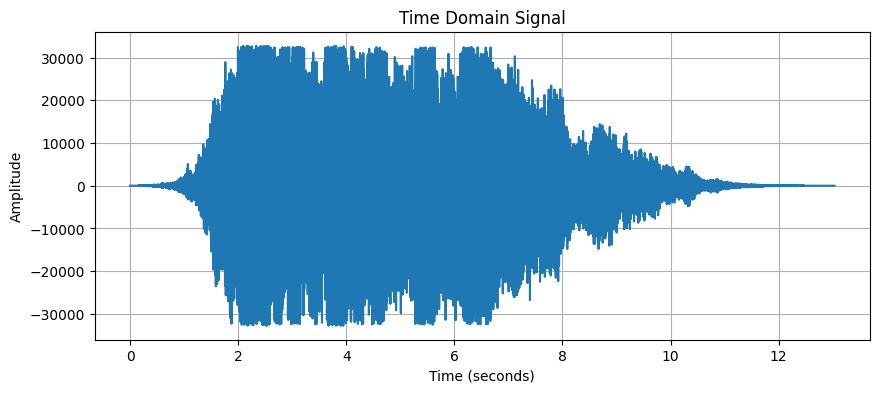

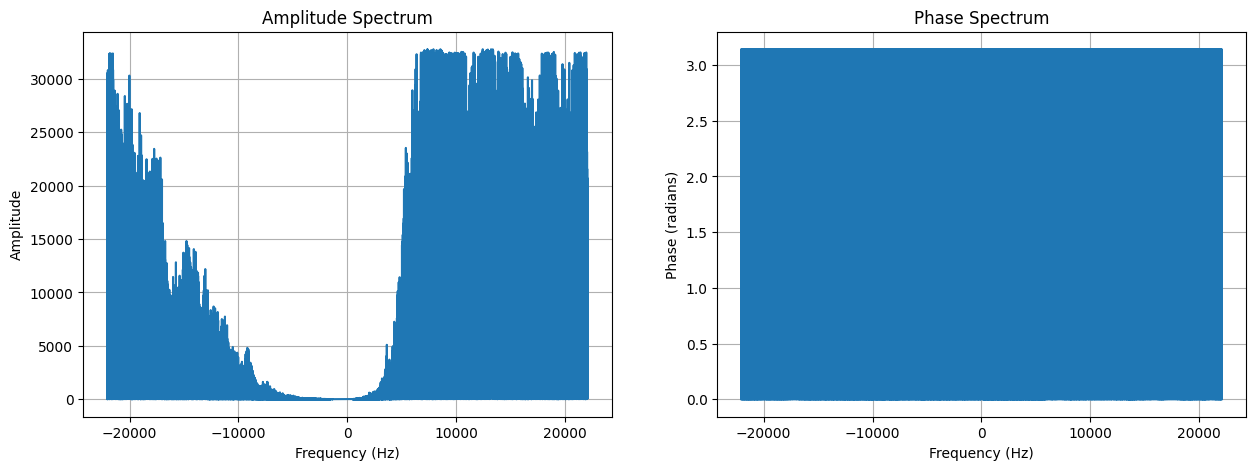

In [6]:
import scipy.io.wavfile as wavfile
import numpy as np
import matplotlib.pyplot as plt

fs, signal = wavfile.read('speech.wav')
print(f"Sampling frequency: {fs} Hz")

if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

# Plot the signal in the time domain
plot_time(signal, fs)

# Plot the signal in the frequency domain
plot_freq(signal, fs)



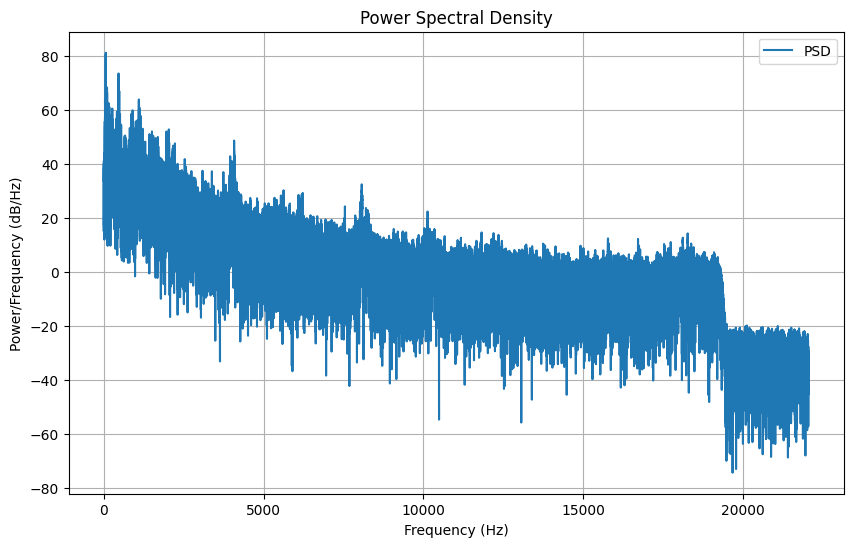

In [7]:
# Compute and plot the PSD
N = len(signal)
window = np.hanning(N)  # Use Hanning window
frequencies, psd_values = psd(signal, window, fs)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, 10 * np.log10(psd_values), label="PSD")
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()
plt.show()

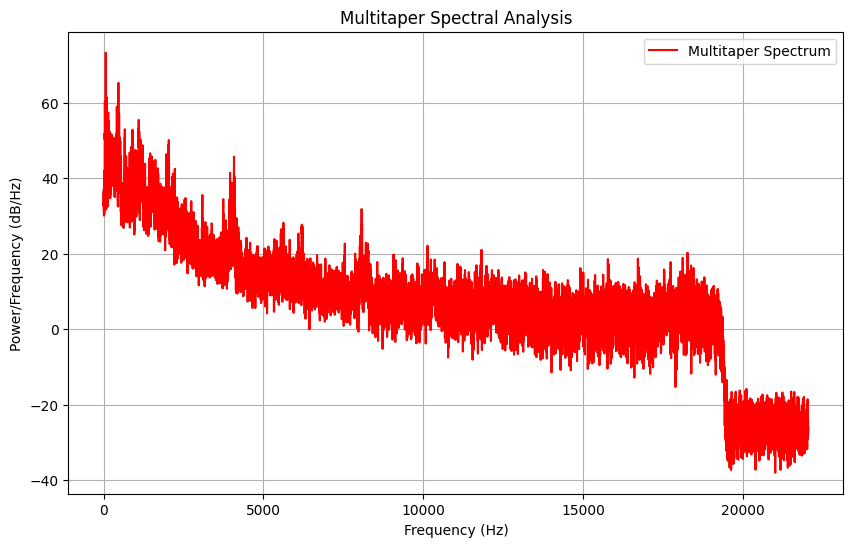

In [8]:

# Compute and plot the multitaper spectrum using 20 tapers
frequencies, multitaper_values = multitaper(signal, fs, k=20)

plt.figure(figsize=(10, 6))
plt.plot(frequencies, 10 * np.log10(multitaper_values), label="Multitaper Spectrum", color='r')
plt.title("Multitaper Spectral Analysis")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.grid()
plt.legend()
plt.show()


# Question 3

In [9]:
import numpy as np
from scipy.signal.windows import hann

def stft(x, fs, wlen, win_func=False):

    N = len(x)
    # Samples per window
    window_length = int(fs * wlen)  
    # Number of windows
    n_windows = N // window_length 
    # Frequency and time arrays
    freqs = np.fft.fftfreq(window_length, d=1/fs)[:window_length//2 + 1]
    times = np.arange(0, n_windows) * wlen
    
    # Hann window function
    if win_func:
        window = hann(window_length)
    else:
        window = np.ones(window_length)

    stft_matrix = []
    
    for i in range(n_windows):
        segment = x[i * window_length : (i + 1) * window_length]
        if len(segment) < window_length:  # Ensure all segments are same length
            break
        segment = segment * window  # Apply window function
        spectrum = np.fft.fft(segment)[:window_length//2 + 1]  # Positive frequencies only
        stft_matrix.append(spectrum)
    
    stft_matrix = np.array(stft_matrix).T  # Transpose for correct shape
    return stft_matrix, freqs, times


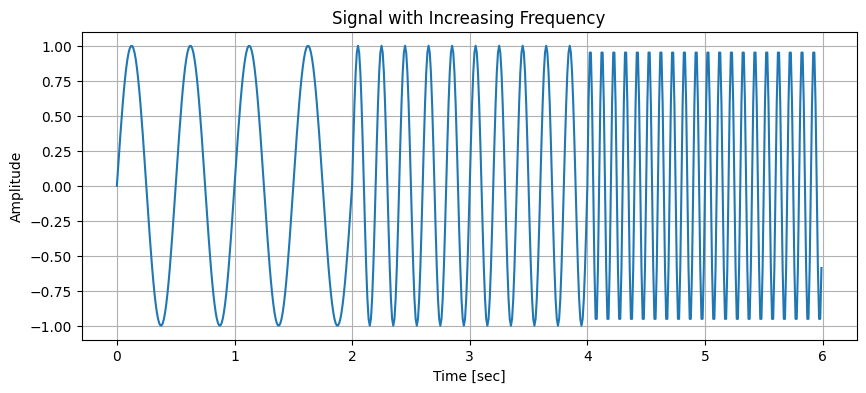

In [10]:
import matplotlib.pyplot as plt

# Define the signal
fs = 100  # Sampling frequency
t = np.arange(0, 6, 1/fs)  # Time vector from 0 to 6 seconds
signal = np.piecewise(t, 
                      [t < 2, (t >= 2) & (t < 4), t >= 4],
                      [lambda t: np.sin(2 * np.pi * 2 * t),  # 2 Hz
                       lambda t: np.sin(2 * np.pi * 5 * t),  # 5 Hz
                       lambda t: np.sin(2 * np.pi * 10 * t)])  # 10 Hz

# Plot the signal in the time domain
plt.figure(figsize=(10, 4))
plt.plot(t, signal)
plt.title("Signal with Increasing Frequency")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


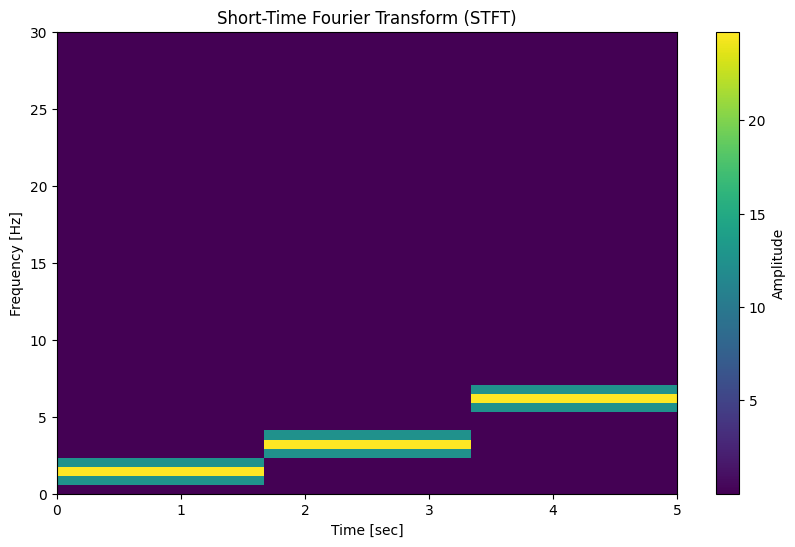

In [11]:
def plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=None, log=False, colormap_min=None, colormap_max=None):

    magnitude = np.abs(stft_matrix)
    if log:
        magnitude = np.log(magnitude + 1e-10)  # Avoid log(0)
    
    plt.figure(figsize=(10, 6))
    extent = [times[0], times[-1], freqs[0], fmax or freqs[-1]]
    plt.imshow(magnitude, aspect='auto', origin='lower', extent=extent, vmin=colormap_min, vmax=colormap_max)
    plt.colorbar(label="Amplitude")
    plt.title("Short-Time Fourier Transform (STFT)")
    plt.xlabel("Time [sec]")
    plt.ylabel("Frequency [Hz]")
    plt.show()

# Compute the STFT
wlen = 1.0  # Window length in seconds
stft_matrix, freqs, times = stft(signal, fs, wlen, win_func=True)

# Plot the STFT
plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=30)


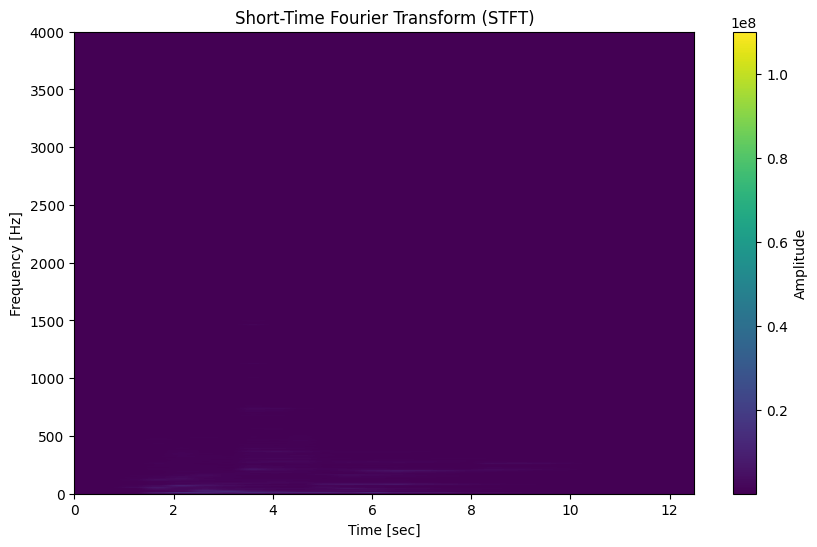

In [12]:
from scipy.io.wavfile import read

# Load the audio file
fs, speech_signal = read('speech.wav')

# Convert to mono if stereo
if len(speech_signal.shape) == 2:
    speech_signal = speech_signal.mean(axis=1)

# Compute the STFT
wlen = 0.5  # Window length in seconds
stft_matrix, freqs, times = stft(speech_signal, fs, wlen, win_func=True)

# Plot the STFT with suitable fmax
plot_colormap_stft(stft_matrix, fs, times, freqs, fmax=4000)


# Question 4

In [13]:
!pip install scipy sounddevice


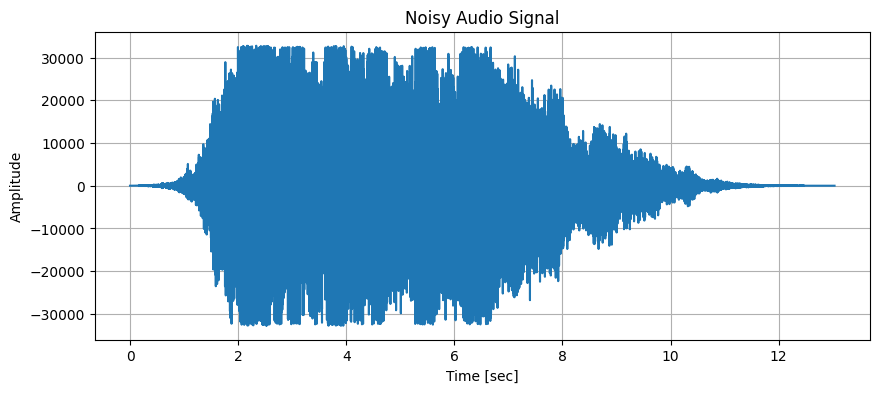

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io.wavfile import read

# Load the noisy audio file
fs, noisy_signal = read("noisy.wav")

# Convert to mono if stereo
if len(noisy_signal.shape) == 2:
    noisy_signal = noisy_signal.mean(axis=1)

# Play the noisy audio
sd.play(noisy_signal, fs)

# Time vector
t = np.linspace(0, len(noisy_signal) / fs, len(noisy_signal))

# Plot the noisy signal in the time domain
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_signal)
plt.title("Noisy Audio Signal")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


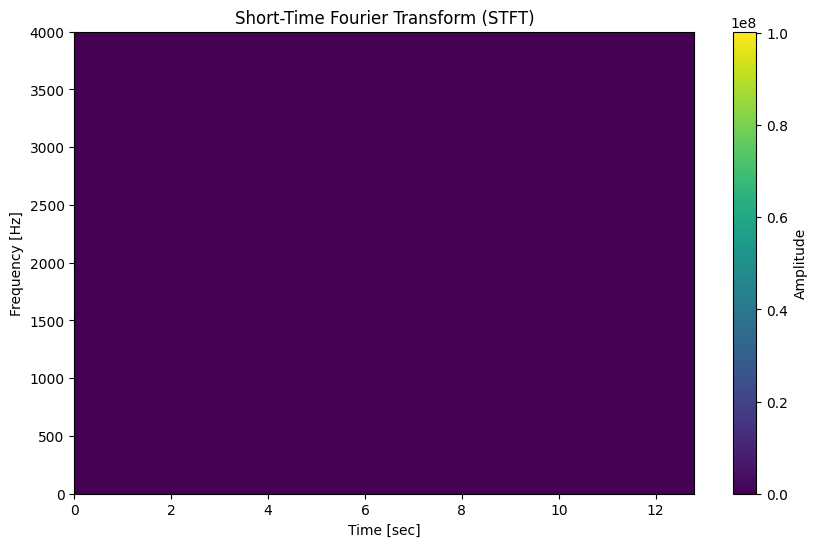

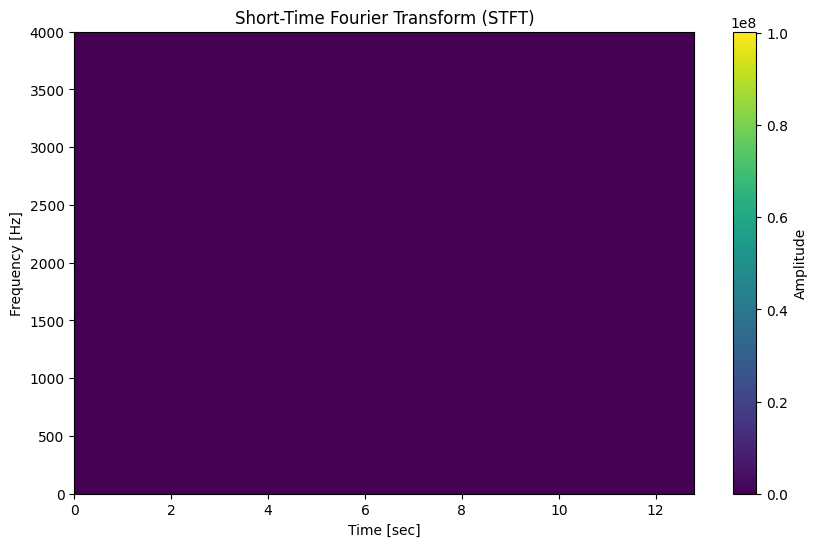

Frequency resolution: 5.0 Hz


In [15]:
# Import the previously defined STFT and plotting function
from scipy.signal.windows import hann

# Parameters
wlen = 0.2  # Window length in seconds
window_length = int(fs * wlen)

# STFT with rectangular window
stft_rect, freqs, times = stft(noisy_signal, fs, wlen, win_func=False)

# STFT with Hann window
stft_hann, freqs, times = stft(noisy_signal, fs, wlen, win_func=True)

# Maximum amplitude for consistent color scale
max_amplitude = max(np.abs(stft_rect).max(), np.abs(stft_hann).max())

# Plot STFT with rectangular window
plot_colormap_stft(stft_rect, fs, times, freqs, fmax=4000, log=True, colormap_min=0, colormap_max=max_amplitude)

# Plot STFT with Hann window
plot_colormap_stft(stft_hann, fs, times, freqs, fmax=4000, log=True, colormap_min=0, colormap_max=max_amplitude)

# Frequency resolution
frequency_resolution = fs / window_length
print(f"Frequency resolution: {frequency_resolution} Hz")


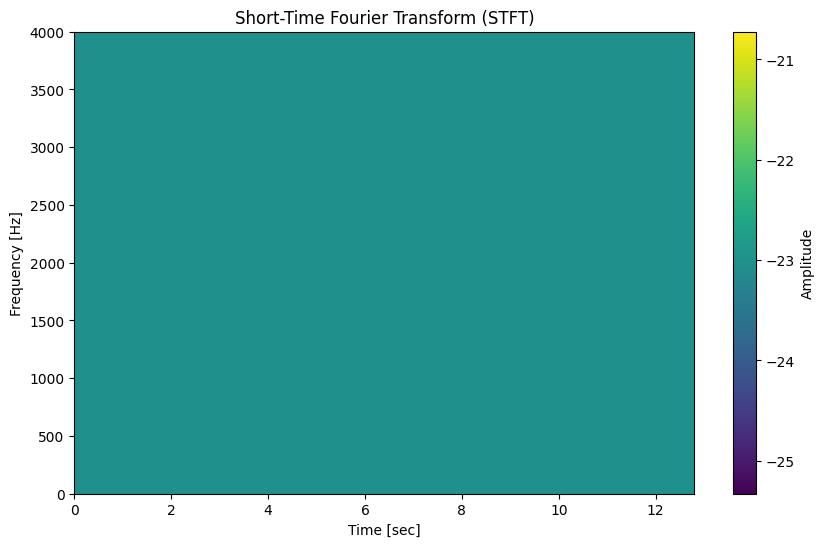

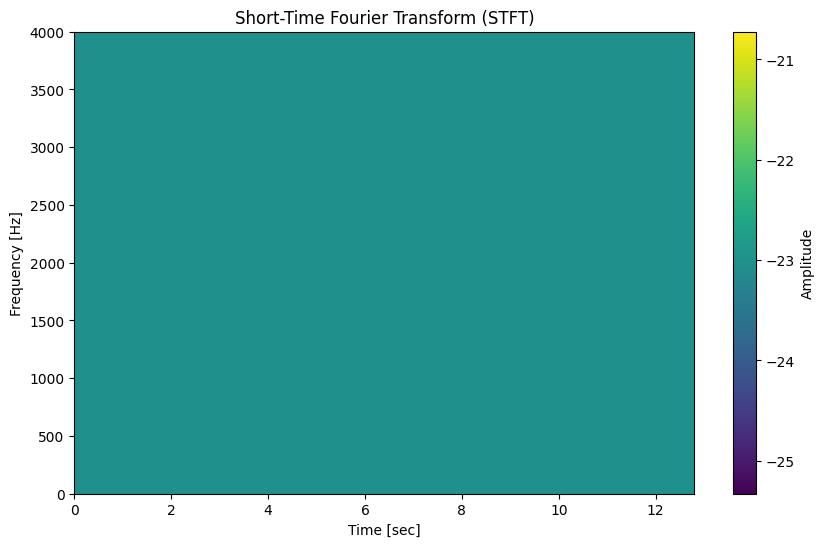

In [20]:
def noise_gate(W, t_noise, c_thresh):

    # Identify noise epoch (first t_noise seconds)
    noise_idx = int(t_noise / wlen)
    noise_matrix = W[:, :noise_idx]
    
    # Calculate log-scaled mean and std per frequency
    log_amplitude = np.log(np.abs(noise_matrix) + 1e-10)
    mu = np.mean(log_amplitude, axis=1)  # Mean
    sigma = np.std(log_amplitude, axis=1)  # Std
    
    # Threshold calculation
    thresh = mu[:, np.newaxis] + c_thresh * sigma[:, np.newaxis]
    
    # Apply noise gate
    log_W = np.log(np.abs(W) + 1e-10)
    W_clean = np.where(log_W >= thresh, W, 0)
    
    return W_clean

# Apply noise gate with c_thresh=3
W_clean_rect = noise_gate(stft_rect, t_noise=5, c_thresh=3)
W_clean_hann = noise_gate(stft_hann, t_noise=5, c_thresh=3)

# Plot cleaned spectra
plot_colormap_stft(W_clean_rect, fs, times, freqs, fmax=4000, log=True)
plot_colormap_stft(W_clean_hann, fs, times, freqs, fmax=4000, log=True)


C:\Users\abhad\AppData\Local\Temp\ipykernel_18524\3003540153.py:21: RuntimeWarning: invalid value encountered in divide
  z_clean_rect = np.int16(z_clean_rect / np.max(np.abs(z_clean_rect)) * 32767)
C:\Users\abhad\AppData\Local\Temp\ipykernel_18524\3003540153.py:21: RuntimeWarning: invalid value encountered in cast
  z_clean_rect = np.int16(z_clean_rect / np.max(np.abs(z_clean_rect)) * 32767)
C:\Users\abhad\AppData\Local\Temp\ipykernel_18524\3003540153.py:22: RuntimeWarning: invalid value encountered in divide
  z_clean_hann = np.int16(z_clean_hann / np.max(np.abs(z_clean_hann)) * 32767)
C:\Users\abhad\AppData\Local\Temp\ipykernel_18524\3003540153.py:22: RuntimeWarning: invalid value encountered in cast
  z_clean_hann = np.int16(z_clean_hann / np.max(np.abs(z_clean_hann)) * 32767)


Playing cleaned audio (Rectangular Window):
Playing cleaned audio (Hann Window):


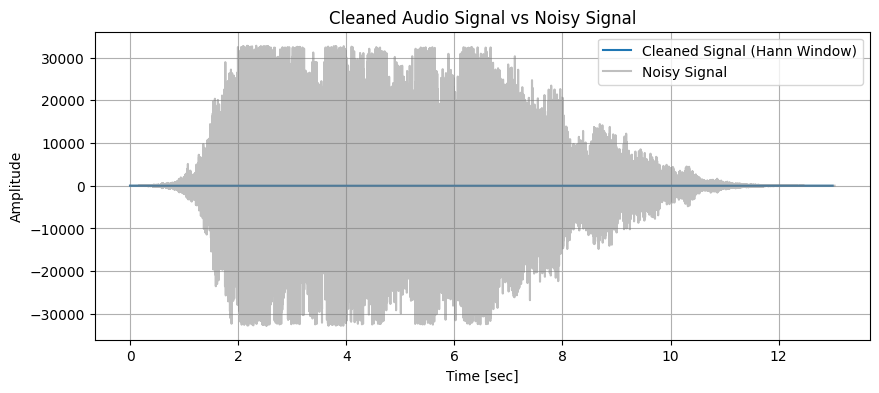

In [22]:
from scipy.io.wavfile import write

def istft(X_stft):

    n_windows, n_freqs = X_stft.shape[1], X_stft.shape[0]
    window_length = (n_freqs - 1) * 2
    signal_length = n_windows * window_length
    x_reconstructed = np.zeros(signal_length)

    for i in range(n_windows):
        segment = np.fft.ifft(np.concatenate([X_stft[:, i], np.conj(X_stft[-2:0:-1, i])])).real
        x_reconstructed[i * window_length: (i + 1) * window_length] += segment

    return x_reconstructed

# Reconstruct signals
z_clean_rect = istft(W_clean_rect)
z_clean_hann = istft(W_clean_hann)

# Scale signals
z_clean_rect = np.int16(z_clean_rect / np.max(np.abs(z_clean_rect)) * 32767)
z_clean_hann = np.int16(z_clean_hann / np.max(np.abs(z_clean_hann)) * 32767)

# Save cleaned audio
write("cleaned_rect.wav", fs, z_clean_rect)
write("cleaned_hann.wav", fs, z_clean_hann)

# Play the cleaned audio
print("Playing cleaned audio (Rectangular Window):")
sd.play(z_clean_rect, fs)
sd.wait()

print("Playing cleaned audio (Hann Window):")
sd.play(z_clean_hann, fs)
sd.wait()

# Recompute the time vector based on the cleaned signal length
t_clean = np.linspace(0, len(z_clean_hann) / fs, len(z_clean_hann))

# Plot cleaned audio signal vs noisy signal
plt.figure(figsize=(10, 4))
plt.plot(t_clean, z_clean_hann, label="Cleaned Signal (Hann Window)")
plt.plot(t[:len(noisy_signal)], noisy_signal[:len(t)], alpha=0.5, label="Noisy Signal", color='gray')
plt.title("Cleaned Audio Signal vs Noisy Signal")
plt.xlabel("Time [sec]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()



## Question 4

In [16]:
!pip install scipy sounddevice


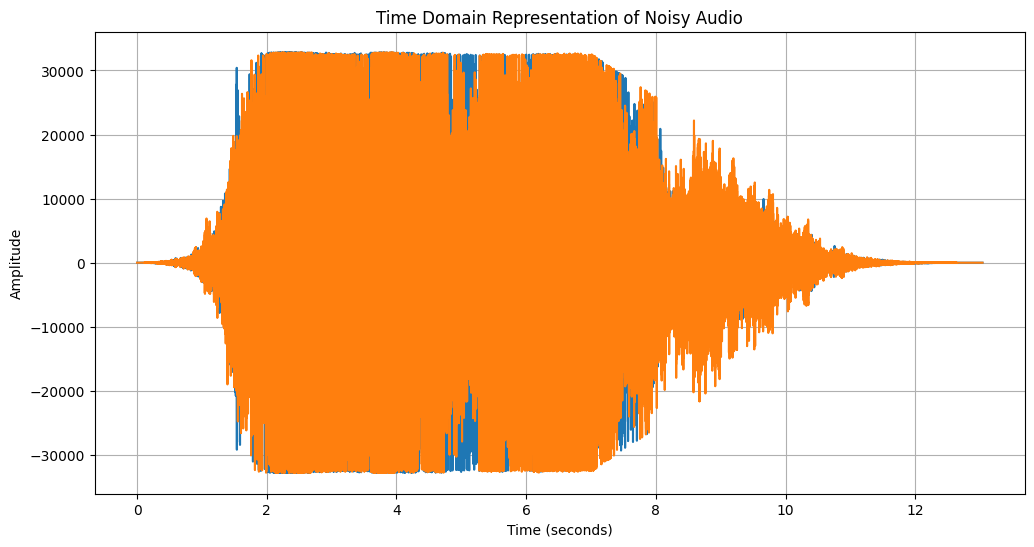

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import sounddevice as sd

# Load the audio file
fs, x = wavfile.read('speech.wav')  # Make sure to provide the correct path to the file

# Play the audio file
sd.play(x, fs)
sd.wait()  # Wait until the file is played completely

# Plot the audio signal in the time domain
t = np.linspace(0, len(x) / fs, num=len(x), endpoint=False)  # Time vector in seconds

plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Time Domain Representation of Noisy Audio')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal.windows import hann

def stft(x, fs, wlen, win_func=False):
    sample_per_window = int(wlen * fs)
    n_windows = len(x) // sample_per_window
    stft_output = np.zeros((n_windows, sample_per_window // 2 + 1), dtype=complex)
    window = hann(sample_per_window) if win_func else np.ones(sample_per_window)
    
    for i in range(n_windows):
        start_idx = i * sample_per_window
        end_idx = start_idx + sample_per_window
        segment = x[start_idx:end_idx]
        segment = segment * window  # Apply the window function
        stft_output[i, :] = np.fft.rfft(segment)
    
    return stft_output

def plot_stft(x_stft, fs, wlen, fmax=None, log=False, colormap_min=None, colormap_max=None):
    time_step = wlen
    freq_step = fs / (len(x_stft[0]) * 2)
    extent = [0, len(x_stft) * time_step, 0, fs / 2]
    
    plt.figure(figsize=(12, 6))
    if log:
        plt.imshow(np.log(np.abs(x_stft.T) + 1), aspect='auto', origin='lower',
                   extent=extent, vmin=colormap_min, vmax=colormap_max, cmap='viridis')
    else:
        plt.imshow(np.abs(x_stft.T), aspect='auto', origin='lower',
                   extent=extent, vmin=colormap_min, vmax=colormap_max, cmap='viridis')
    plt.colorbar(label='Amplitude (Log scale)')
    plt.title('STFT Magnitude Spectrum')
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (seconds)')
    plt.show()

# Load audio data
fs, x = wavfile.read('speech.wav')

# Compute the STFT with and without the Hann window
wlen = 0.2
stft_no_window = stft(x, fs, wlen, win_func=False)
stft_hann_window = stft(x, fs, wlen, win_func=True)

# Find max amplitude for consistent color scaling
max_amplitude = max(np.max(np.abs(stft_no_window)), np.max(np.abs(stft_hann_window)))

# Plotting
plot_stft(stft_no_window, fs, wlen, log=True, colormap_min=0, colormap_max=max_amplitude)
plot_stft(stft_hann_window, fs, wlen, log=True, colormap_min=0, colormap_max=max_amplitude)

# Frequency resolution
freq_res = fs / (int(wlen * fs))
print(f"Frequency resolution: {freq_res} Hz")


ValueError: operands could not be broadcast together with shapes (8820,2) (8820,) 

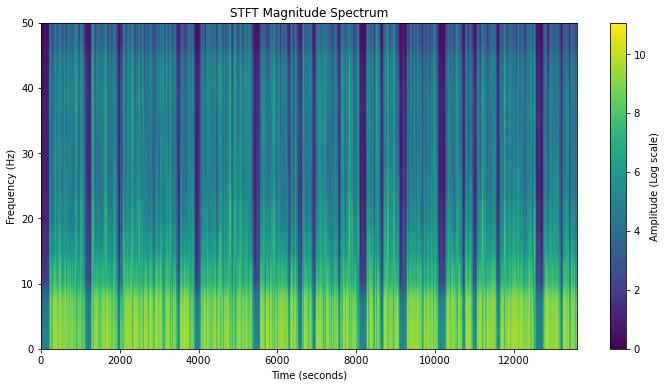

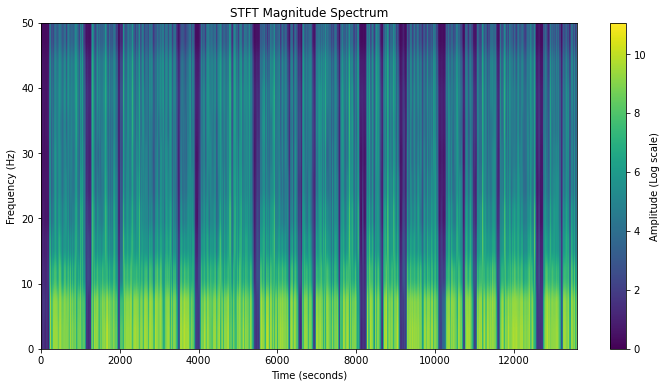

In [31]:
import numpy as np

def noise_gate(W, t_noise, c_thresh, fs):
    # Calculate the number of samples in the noise epoch
    samples_in_noise = int(t_noise * fs)
    
    # Since each segment is 0.2 seconds (given wlen=0.2 from earlier parts), calculate how many segments this includes
    segments_in_noise = int(samples_in_noise / (0.2 * fs))
    
    # Extract the noise-only segments from W
    W_noise = W[:segments_in_noise, :]
    
    # Compute the mean (µ) and standard deviation (σ) of the log-scaled amplitudes in the noise segments
    log_amplitudes = np.log(np.abs(W_noise) + 1)  # Adding 1 to avoid log(0)
    mu = np.mean(log_amplitudes, axis=0)
    sigma = np.std(log_amplitudes, axis=0)
    
    # Calculate the noise gate threshold
    threshold = mu + (c_thresh * sigma)
    
    # Apply the noise gate to the entire matrix W
    W_clean = np.copy(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            if np.log(np.abs(W[i, j]) + 1) < threshold[j]:
                W_clean[i, j] = 0  # Setting the amplitude to zero if below threshold

    return W_clean

# Example Usage
fs = 100  # Example sampling frequency in Hz
W = stft(x, fs, 0.2, win_func=True)  # Assuming 'x' is loaded and 'stft' is already defined
W_clean = noise_gate(W, t_noise=5, c_thresh=1.5, fs=fs)  # Example threshold factor

# Plot the original and cleaned STFT
plot_stft(W, fs, 0.2, log=True, colormap_min=None, colormap_max=None)
plot_stft(W_clean, fs, 0.2, log=True, colormap_min=None, colormap_max=None)


In [32]:
import numpy as np

def istft(X_stft, fs, wlen, win_func=False):
    n_windows, n_frequencies = X_stft.shape
    sample_per_window = int(wlen * fs)
    # Initialize the time-domain signal
    x_reconstructed = np.zeros(n_windows * sample_per_window)
    window = np.hanning(sample_per_window) if win_func else np.ones(sample_per_window)
    
    for i in range(n_windows):
        start_idx = i * sample_per_window
        # Compute the inverse FFT
        ifft_segment = np.fft.irfft(X_stft[i, :])
        # Apply the window and add to the output signal
        x_reconstructed[start_idx:start_idx + sample_per_window] += ifft_segment * window
    
    return x_reconstructed

# Parameters
fs = 100  # Example sampling frequency in Hz, adjust as needed
wlen = 0.2  # Window length of 0.2 seconds


In [33]:
# Compute the inverse STFT for both windowed and non-windowed cleaned signals
z_clean_no_window = istft(W_clean, fs, wlen, win_func=False)
z_clean_hann_window = istft(W_clean, fs, wlen, win_func=True)

# Scaling the signals to 16-bit integer range
z_clean_no_window_scaled = np.int16(z_clean_no_window / np.max(np.abs(z_clean_no_window)) * 32767)
z_clean_hann_window_scaled = np.int16(z_clean_hann_window / np.max(np.abs(z_clean_hann_window)) * 32767)

# Saving the cleaned audio signals
from scipy.io.wavfile import write

write('cleaned_no_window.wav', fs, z_clean_no_window_scaled)
write('cleaned_hann_window.wav', fs, z_clean_hann_window_scaled)


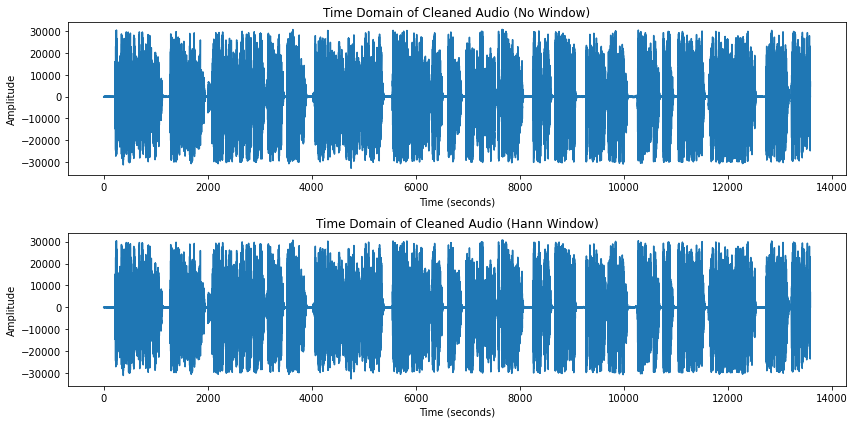

In [34]:
import matplotlib.pyplot as plt

# Time vectors for plotting
t = np.linspace(0, len(z_clean_no_window) / fs, num=len(z_clean_no_window))

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, z_clean_no_window_scaled)
plt.title('Time Domain of Cleaned Audio (No Window)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(t, z_clean_hann_window_scaled)
plt.title('Time Domain of Cleaned Audio (Hann Window)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()


## Question 5

In [23]:
import numpy as np
from numpy.fft import fft, ifft, fftshift
import matplotlib.pyplot as plt

def ideal_lowpass(fc, fs, M):

    # Frequency resolution
    fres = fs / M
    f = np.linspace(-fs / 2, fs / 2, M)
    
    # Define amplitude spectrum
    H0 = np.where(np.abs(f) <= fc, 1, 0)
    
    # Compute impulse response using inverse FFT
    h0 = fftshift(np.real(ifft(fftshift(H0))))
    
    return H0, h0


In [24]:
def hann_window(M):

    n = np.arange(M)
    w = 0.5 - 0.5 * np.cos(2 * np.pi * n / (M - 1))
    return w


In [25]:
def fir_lowpass(fc, fs, M):

    # Design ideal low-pass filter
    H0, h0 = ideal_lowpass(fc, fs, M)
    
    # Generate Hann window
    w_hann = hann_window(M)
    
    # Multiply ideal impulse response with window
    h_fir = h0 * w_hann
    
    # Compute amplitude spectrum
    H_fir = fftshift(np.abs(fft(h_fir)))
    
    return H_fir, h_fir


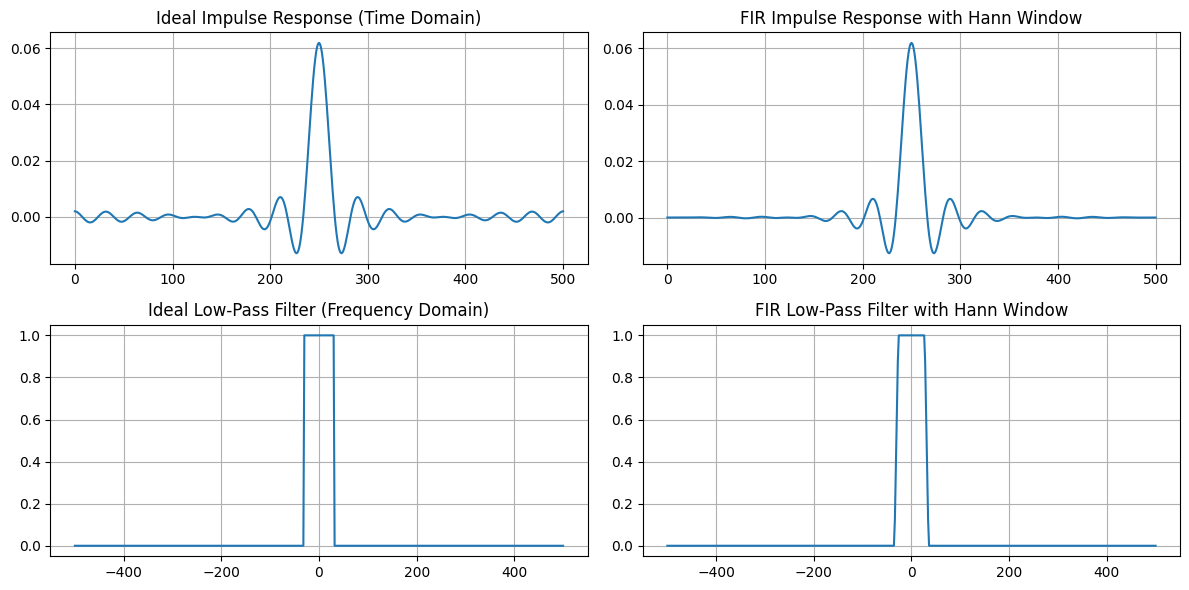

In [26]:
# Parameters
M = 501  # Filter length
fc = 30  # Cut-off frequency
fs = 1000  # Sampling frequency

# Design filters
H0, h0 = ideal_lowpass(fc, fs, M)
H_fir, h_fir = fir_lowpass(fc, fs, M)

# Plot impulse responses
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(h0, label="Ideal Impulse Response")
plt.title("Ideal Impulse Response (Time Domain)")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(h_fir, label="FIR Impulse Response")
plt.title("FIR Impulse Response with Hann Window")
plt.grid()

# Plot amplitude spectra
frequencies = np.linspace(-fs/2, fs/2, M)
plt.subplot(2, 2, 3)
plt.plot(frequencies, H0, label="Ideal Filter")
plt.title("Ideal Low-Pass Filter (Frequency Domain)")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(frequencies, H_fir, label="FIR Filter")
plt.title("FIR Low-Pass Filter with Hann Window")
plt.grid()
plt.tight_layout()
plt.show()


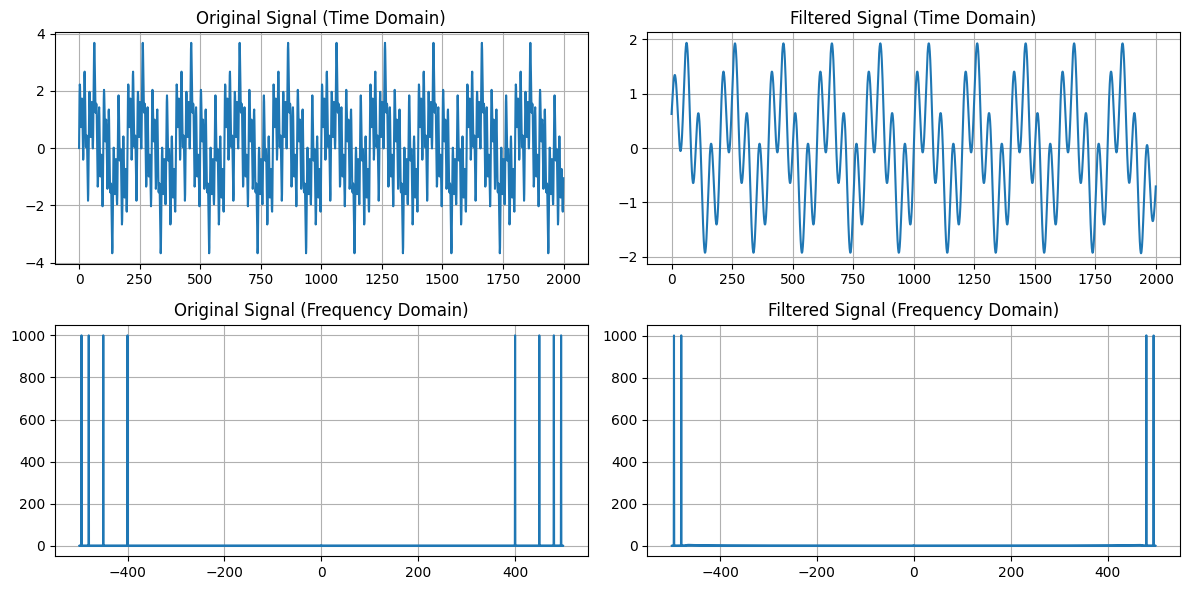

In [27]:
# Define multi-frequency signal
fs = 1000  # Sampling frequency
N = 2000  # Signal length
n = np.arange(N)
x = (np.sin(2 * np.pi * 5 * n / fs) + 
     np.sin(2 * np.pi * 20 * n / fs) +
     np.sin(2 * np.pi * 50 * n / fs) +
     np.sin(2 * np.pi * 100 * n / fs))

# Apply FIR filter using convolution
h_fir = fir_lowpass(fc=30, fs=fs, M=501)[1]
x_filt = np.convolve(x, h_fir, mode='same')

# Plot time and frequency domains
frequencies = np.fft.fftfreq(N, 1/fs)
X = np.fft.fft(x)
X_filt = np.fft.fft(x_filt)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(n, x)
plt.title("Original Signal (Time Domain)")
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(n, x_filt)
plt.title("Filtered Signal (Time Domain)")
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(frequencies, np.abs(np.fft.fftshift(X)))
plt.title("Original Signal (Frequency Domain)")
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(frequencies, np.abs(np.fft.fftshift(X_filt)))
plt.title("Filtered Signal (Frequency Domain)")
plt.grid()
plt.tight_layout()
plt.show()


In [28]:
from scipy.io.wavfile import read, write

# Load Beethoven audio file
fs, audio = read("beethoven.wav")

# Convert to mono
if len(audio.shape) == 2:
    audio = audio.mean(axis=1)

# Define downsampling factors
c_down_factors = [5, 10, 20]

for c_down in c_down_factors:
    # Naive downsampling
    audio_down_naive = audio[::c_down]
    fs_down = fs // c_down
    
    # Proper downsampling
    fc = fs / (2 * c_down)
    h_fir = fir_lowpass(fc, fs, 501)[1]
    audio_filtered = np.convolve(audio, h_fir, mode='same')
    audio_down_proper = audio_filtered[::c_down]
    
    # Save audio
    write(f"audio_down_naive_{c_down}.wav", fs_down, np.int16(audio_down_naive))
    write(f"audio_down_proper_{c_down}.wav", fs_down, np.int16(audio_down_proper))
    
    # Print results
    print(f"Factor: {c_down}, Sampling Rate: {fs_down} Hz, Length: {len(audio_down_proper)} samples")


Factor: 5, Sampling Rate: 8820 Hz, Length: 114970 samples
Factor: 10, Sampling Rate: 4410 Hz, Length: 57485 samples
Factor: 20, Sampling Rate: 2205 Hz, Length: 28743 samples


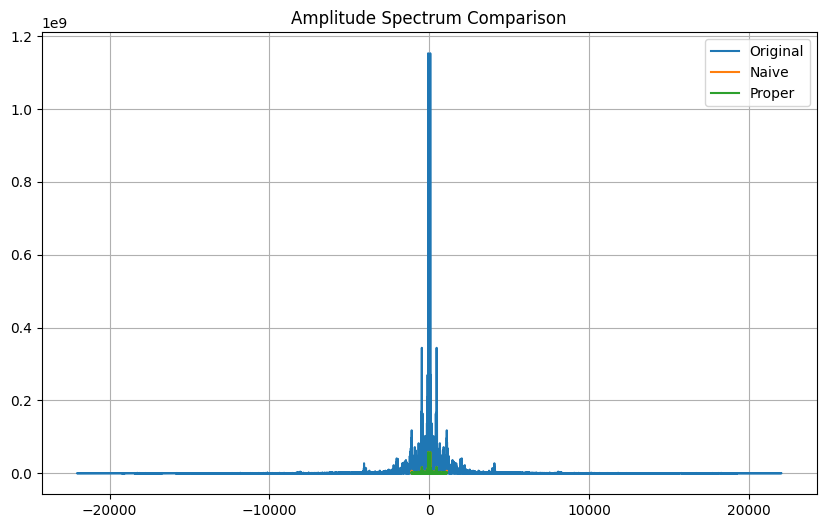

In [29]:
# Plot spectra for original, naive, and proper downsampling
plt.figure(figsize=(10, 6))
plt.plot(np.fft.fftfreq(len(audio), 1/fs), np.abs(np.fft.fft(audio)), label="Original")
plt.plot(np.fft.fftfreq(len(audio_down_naive), 1/fs_down), np.abs(np.fft.fft(audio_down_naive)), label="Naive")
plt.plot(np.fft.fftfreq(len(audio_down_proper), 1/fs_down), np.abs(np.fft.fft(audio_down_proper)), label="Proper")
plt.legend()
plt.title("Amplitude Spectrum Comparison")
plt.grid()
plt.show()
